
#**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

**Edición 2025**

---
## Trabajo práctico entregable - Parte 1

# Ejercicio 1 - Análisis descriptivo

Responder a la pregunta: **¿Cuáles son los lenguajes de programación asociados a los mejores salarios?**

Para ello:
1. Seleccionar las columnas relevantes para analizar.
2. Seleccionar las filas relevantes para analizar. Esto incluye la eliminación de valores extremos y erróneos, pero también puede enfocar el análisis en una sub-población. Por ejemplo, se pueden limitar a personas con un salario mayor que 300000 pesos, o a las personas que trabajan sólo en "Data Science", pero deben justificar su elección y reformular la pregunta inicial de ser necesario.
  * Obtener una lista de los lenguajes de programación más populares. Decidir cuántos y cuáles seleccionan para incluir en el análisis.
  * Para cada una de las otras columnas del punto anterior, elegir los rangos o valores seleccionan para incluir en el análisis.
3. Seleccionar métricas que ayuden a responder la pregunta, y los métodos para analizarlas. Elegir UNA de las siguientes opciones:
  * Comparar las distribuciones de salario para cada lenguaje utilizando visualizaciones. Como la visualización es el producto final, debe ser clara y mostrar información relevante.
  * Comparar medidas de estadística descriptiva sobre la distribución de salario para cada lenguaje. Sean creativos, la estadística descriptiva nos permite decir cosas como: "el 10% de los mejores sueldos los ganan, en su mayoría, programadores que saben kotlin!" (donde *mayoría* es un término medio engañoso que sólo significa más del 50%). Para comparar múltiples lenguajes, les recomendamos usar también visualizaciones.
  * Comparar probabilidades. Por ejemplo: "Si sabés Python o Java, tenés un 30% más de chances de ganar arriba de 1000K".

Si lo consideran necesario, realicen varias iteraciones. Es decir, si encuentran que las distribuciones de los lenguajes de programación que seleccionaron inicialmente no son muy diferentes, pueden re-hacer el análisis usando sólo los lenguajes de programación que son diferentes.

In [ ]:
import io
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn

seaborn.set_context('talk')

In [ ]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/master/sysarmy_survey_2025_processed.csv'
df = pd.read_csv(url)

Las columnas seleccionadas para el análisis fueron: lenguajes de programación, salario neto y tipo de dedicación (Part-Time o Full-Time). Esta última se incluyó con el objetivo de calcular el sueldo por hora de los trabajadores, un aspecto que se desarrolla con mayor detalle más adelante.


In [ ]:
relevant_columns = ['tools_programming_languages', 'salary_monthly_NETO', 'work_dedication']

In [ ]:
df= df[relevant_columns]

Para seleccionar las filas relevantes analizamos la distribucion de salario neto, en la cual vimos que tanto el valor mínimo como el máximo son valores atípicos que no se corresponden con salarios reales.

En particular, tomamos como limite superior 10 millones, que se corresponde con el percentil 99.5. Este corte nos indica que solo un 0.5% de los datos fue descartado (27 filas), dando como resultado una muestra bastante completa pero eliminando los valores extremos presentes en los datos originales.

In [ ]:
df.describe()

,salary_monthly_NETO
count,4.951000e+03
mean,1.072550e+10
std,7.545122e+11
min,4.000000e+00
25%,1.288264e+06
50%,1.916958e+06
75%,2.893500e+06
max,5.309001e+13


In [ ]:
percentil_99 = df['salary_monthly_NETO'].quantile(0.995)
print(f"Percentil 99: {percentil_99}")

Percentil 99: 10147500.0


In [ ]:
# Contar las filas con valores mayores a 10,000,000 en 'salary_neto'
conteo = df[df['salary_monthly_NETO'] > 10000000].shape[0]

print(f"Cantidad de filas con salario mayor a 10 millones: {conteo}")

Cantidad de filas con salario mayor a 10 millones: 27


Por otro lado, para el limite inferior de los salarios tomamos un salario minimo vital y movil (300000 pesos) como corte ya que consideramos que es un valor mas real que el valor minimo que tenian los datos originales ( 4 pesos)

Como filtro adicional, eliminamos las filas que tenian valores nulos en la columna de salario neto.

In [ ]:
df_= df[(df['salary_monthly_NETO'] < 10000000) & (df['salary_monthly_NETO'].notna()) & (df['salary_monthly_NETO'] > 300000)]

La muestra final quedó compuesta por 4852 filas y mostramos su distribucion en el histograma siguiente.

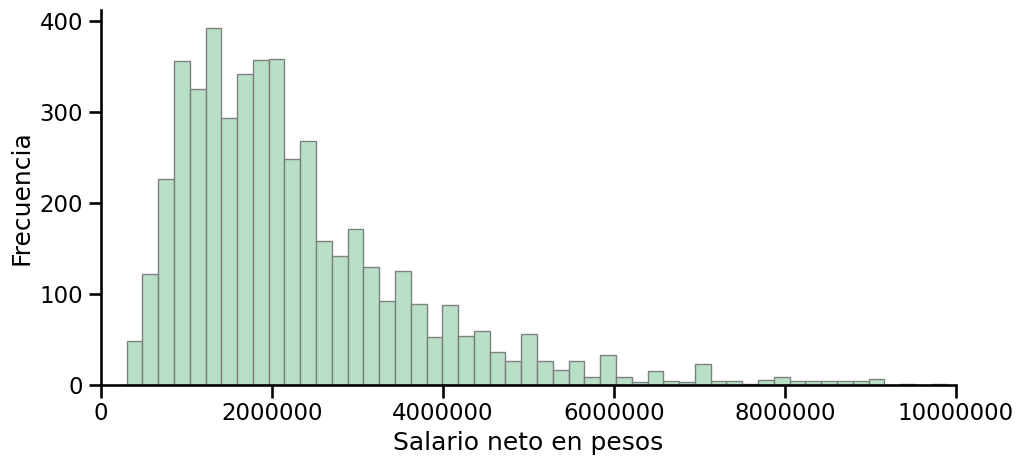

In [ ]:
seaborn.displot(df_['salary_monthly_NETO'], aspect=2,color = "#A0D6B4",edgecolor = "grey", linewidth = 1)
## para evitar la notación científica en las etiquetas
plt.ticklabel_format(style='plain', axis='x')
plt.xlabel ('Salario neto en pesos')
plt.ylabel('Frecuencia')
plt.xlim((0,10000000))
plt.show()

Cortaria de acuerdo al salario, 2 smvm y tal vez en 1 o 2 sigmas para adelante. ver como se puede jutificar eso, pero despues para analizar el lenguaje de programacion mejor pago conviene analizar cuanto pagan por hora. en bs as, despues ver si lo extiendo a las demas provincias.

### Conteo de frecuencias de los lenguajes de programación

Para poder analizar cual es el lenguaje de programacion mejor pago primero analizamos la columna que contiene información sobre los lenguajes de programación utilizados: `tools_programming_languages`. Sus valores son strings con los lenguajes seleccionados separados por comas.



In [ ]:
df_.tools_programming_languages[:3]

,tools_programming_languages
0,Ninguno de los anteriores
2,SQL
3,"Bash/Shell, CSS, HTML, Javascript, PHP, Python"


Las siguientes celdas de código separan estos lenguajes de programación y cuentan la frecuencia con la que aparecen. De esto seleccionamos los 6 lenguajes mas frecuentes para analizar cual es el mejor pago.

In [ ]:
# Convert the comma-separated string of languages to a list of string.
# Remove 'ninguno de los anteriores' option, spaces and training commas.
def split_languages(languages_str):
  if not isinstance(languages_str, str):
    return []
  # Remove 'other' option
  languages_str = languages_str.lower()\
    .replace('ninguno de los anteriores', '')
  # Split string into list of items
  # Remove spaces and commas for each item
  return [lang.strip().replace(',', '')
          for lang in languages_str.split()]

# Create a new column with the list of languages
df_.loc[:, 'cured_programming_languages'] = df_.tools_programming_languages\
    .apply(split_languages)
if 'cured_programming_languages' not in relevant_columns:
    relevant_columns.append('cured_programming_languages')

# Duplicate each row of df_bsas for each programming language
# mentioned in the response.
# We only include in df_lang the columns we are going to analyze later, so we
# don't duplicate innecesary information.
df_lang = df_.cured_programming_languages\
    .apply(pd.Series).stack()\
    .reset_index(level=-1, drop=True).to_frame()\
    .join(df_[relevant_columns])\
    .rename(columns={0: 'programming_language'})
# Horrible programming style! But a lot of data science code can be written with
# as concatenations of functions (pipelines), and there's no elegant way of
# doing that on Python.
#df_lang

In [ ]:
language_count = df_lang.programming_language.value_counts()\
    .reset_index()\
    .rename(columns={'index': 'language', 'programming_language': 'frequency'})
language_count[:10]

,frequency,count
0,sql,2163
1,javascript,1793
2,python,1575
3,html,1298
4,typescript,991
5,css,910
6,bash/shell,834
7,java,793
8,php,605
9,.net,557


De esto vemos que los lenguajes a analizar son: **sql, javascript, python, html, typescript y css. **

## Filtrado de lenguajes relevantes

El siguiente código permite seleccionar sólo las filas donde el valor de la columna `programming_language` se encuentre en la lista `interesting_languages`. Es decir, sea sql, javascript, python, html, typescript o css.

In [ ]:
# Filter out languages that we want to exclude
# Complete here with your selected list.
interesting_languages = ["python", "sql", "javascript", "html", "typescript","css"]
filtered_df_lang = df_lang[df_lang.programming_language.isin(interesting_languages)]
filtered_df_lang

,programming_language,tools_programming_languages,salary_monthly_NETO,work_dedication,cured_programming_languages
2,sql,SQL,3137662.0,Full-Time,[sql]
3,css,"Bash/Shell, CSS, HTML, Javascript, PHP, Python",1360000.0,Part-Time,"[bash/shell, css, html, javascript, php, python]"
3,html,"Bash/Shell, CSS, HTML, Javascript, PHP, Python",1360000.0,Part-Time,"[bash/shell, css, html, javascript, php, python]"
3,javascript,"Bash/Shell, CSS, HTML, Javascript, PHP, Python",1360000.0,Part-Time,"[bash/shell, css, html, javascript, php, python]"
3,python,"Bash/Shell, CSS, HTML, Javascript, PHP, Python",1360000.0,Part-Time,"[bash/shell, css, html, javascript, php, python]"
...,...,...,...,...,...
5192,javascript,"CSS, HTML, Java, Javascript, SQL",1300000.0,Full-Time,"[css, html, java, javascript, sql]"
5192,sql,"CSS, HTML, Java, Javascript, SQL",1300000.0,Full-Time,"[css, html, java, javascript, sql]"
5193,sql,"Bash/Shell, Groovy, Java, Kotlin, SQL",2400000.0,Full-Time,"[bash/shell, groovy, java, kotlin, sql]"
5194,python,"PHP, Python",4200000.0,Full-Time,"[php, python]"


##Análisis de sueldo por hora ##
Como nuestra muestra está formada por salarios que se corresponden tanto a jornadas part-time como full-time, una comparacion mas justa sería analizar cuanto se paga la hora a cada trabajador de acuerdo al lenguaje de programación que conozca. Para hacer esto, vamos a suponer que un trabajo Part-Time consiste en 5 horas y uno Full-Time corresponde a 8 horas de trabajo. Con esto, creamos una nueva columna llamada 'sueldo_por_hora', calculada como el salario neto divido las horas trabajadas en el mes. Esta ultima columna es la analizaremos.

In [ ]:
filtered_df_lang['work_hours'] = filtered_df_lang['work_dedication'].apply(lambda x: 5 if x == 'Part-Time' else 8)
filtered_df_lang['sueldo_por_hora']= (filtered_df_lang['salary_monthly_NETO'] / (5*filtered_df_lang['work_hours']*4))

<ipython-input-26-31bdaed47d21>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_lang['work_hours'] = filtered_df_lang['work_dedication'].apply(lambda x: 5 if x == 'Part-Time' else 8)
<ipython-input-26-31bdaed47d21>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_lang['sueldo_por_hora']= (filtered_df_lang['salary_monthly_NETO'] / (5*filtered_df_lang['work_hours']*4))


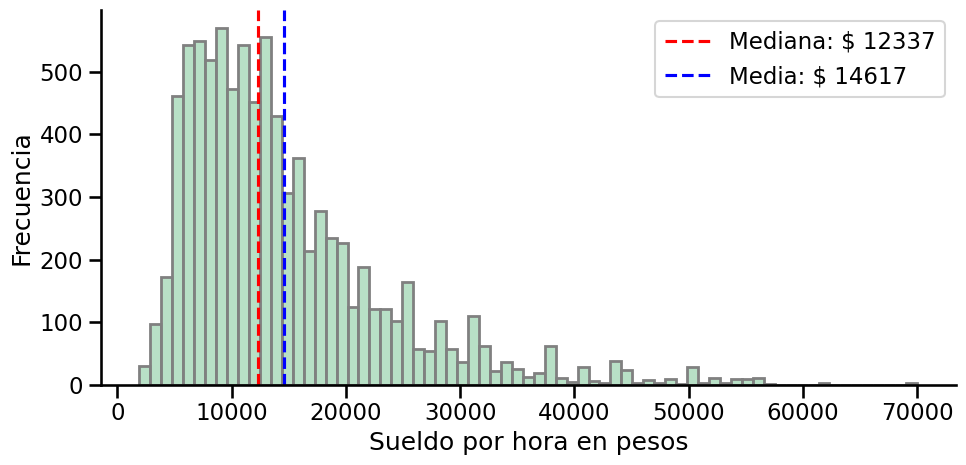

In [ ]:
seaborn.displot(filtered_df_lang['sueldo_por_hora'], aspect=2,color = "#A0D6B4",edgecolor = "grey",
             linewidth = 2)
plt.axvline(x=filtered_df_lang['sueldo_por_hora'].median(), color='red', linestyle='--', label='Mediana: $ 12337')
plt.axvline(x=filtered_df_lang['sueldo_por_hora'].mean(), color='blue', linestyle='--', label='Media: $ 14617')
plt.ticklabel_format(style='plain', axis='x')
plt.xlabel('Sueldo por hora en pesos')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

En el histograma de arriba vemos la distribucion de sueldo por hora de la muestra, junto con la mediana y la media. De esto pudimos ver que la media se encuentra en valores mas altos que la mediana. Esto se debe a que la media es mas sensible a los valores extremos,por lo que el valor que tomaremos para analizar el salario de acuerdo al lenguaje de programación va a ser la mediana.

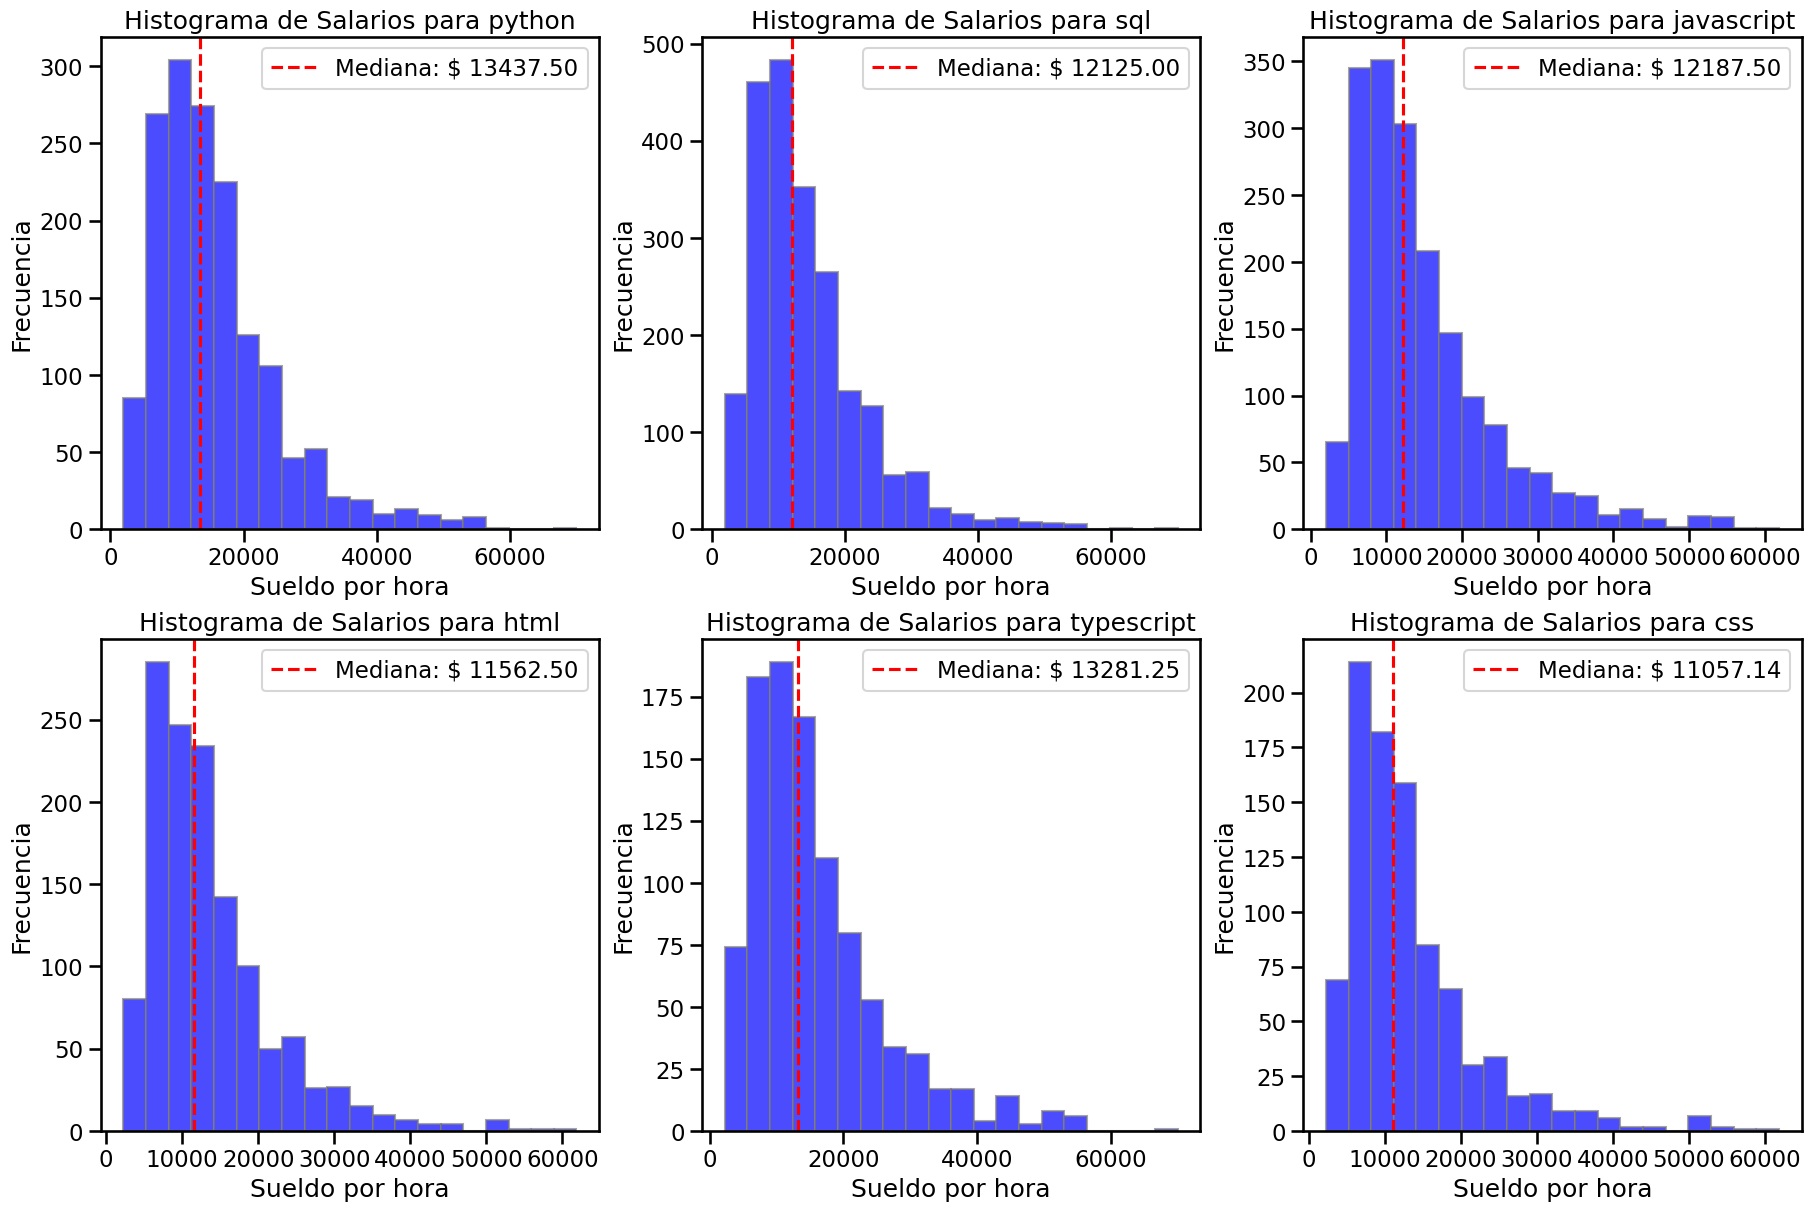

In [ ]:
# Crear subplots: 3 columnas, 2 filas
fig, axes = plt.subplots(2, 3, figsize=(18, 12), constrained_layout=True)
axes = axes.flatten()  # Aplanar para iterar fácilmente

# Crear histogramas para cada lenguaje
for i, lenguaje in enumerate(interesting_languages):
    # Filtrar los datos para el lenguaje actual
    datos_lenguaje = filtered_df_lang[filtered_df_lang['programming_language'] == lenguaje]['sueldo_por_hora']
    # Calcular el salario medio
    salario_medio = datos_lenguaje.median()

    # Crear el histograma
    axes[i].hist(datos_lenguaje, bins=20, alpha=0.7, color='blue', edgecolor='grey')
    axes[i].axvline(x=salario_medio, color='red', linestyle='--', label=f'Mediana: $ {salario_medio:.2f}')
    axes[i].legend()
    axes[i].set_title(f'Histograma de Salarios para {lenguaje}')
    axes[i].set_xlabel('Sueldo por hora')
    axes[i].set_ylabel('Frecuencia')
plt.show()


En cada histograma del subplot de arriba podemos ver la distribucion de sueldo por hora para cada uno de los lenguajes de programación seleccionados junto con la mediana representada con la linea vertical roja a trazos.

Comparando los valores de la mediana de cada salario podemos concluir que python es el lenguaje mejor pago, seguido de typescript.

Otra manera de visualizar esto es en un grafico de barras, donde cada una representa la mediana del sueldo por hora. De este gráfico podemos ver mas rapidamente que python es el lenguaje mejor pago.

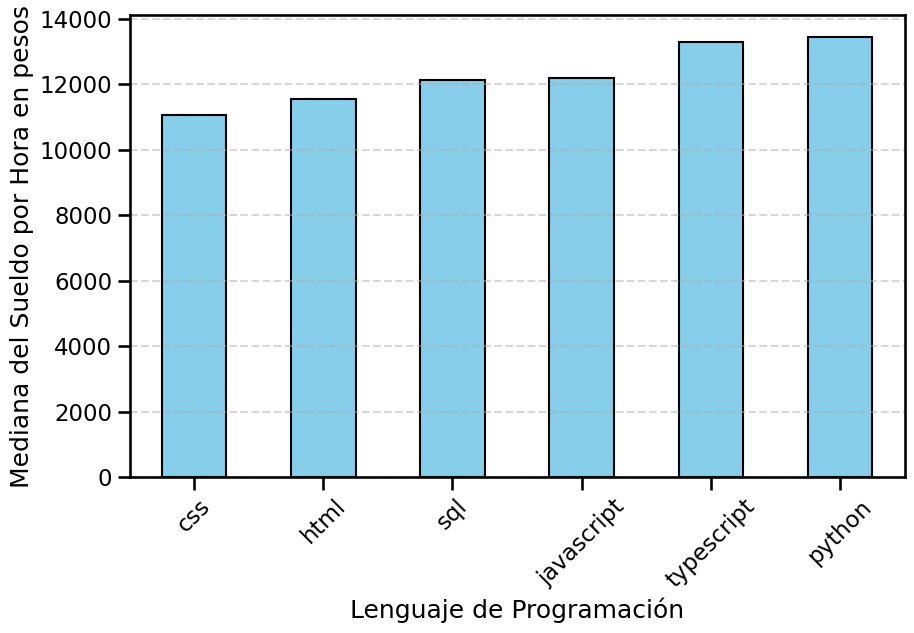

In [ ]:
# Calcular la mediana de los salarios por lenguaje y ordenar
salarios_por_grupo = filtered_df_lang.groupby('programming_language')['sueldo_por_hora'].median().sort_values()

# Crear el gráfico de barras
salarios_por_grupo.plot(kind='bar', color='skyblue', edgecolor='black', figsize=(10, 6))

# Personalizar el gráfico
plt.xlabel('Lenguaje de Programación')
plt.ylabel('Mediana del Sueldo por Hora en pesos')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Mostrar el gráfico
plt.show()

# Ejercicio 2 - Densidades y varias variables

Responder a la pregunta general: **¿Que herramientas (prácticas y teóricas) són útiles para explorar la base, descubrir patrones, asociaciones?**

Para ello considere (igual al ejercicio Anterior):
1. Seleccionar las columnas relevantes para analizar.
2. Seleccionar las filas relevantes para analizar. Esto incluye la eliminación de valores extremos y erróneos, pero también puede enfocar el análisis en sub-poblaciones.

In [ ]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/master/sysarmy_survey_2025_processed.csv'
df1 = pd.read_csv(url)

In [ ]:
relevant_columns = ['work_work_modality','salary_monthly_NETO', 'salary_monthly_BRUTO', 'work_province', 'profile_gender', 'profile_age', 'profile_years_experience', 'profile_studies_level','seniority', 'company_main_activity']

In [ ]:
df1=df1[relevant_columns]

In [ ]:
df1['salary_monthly_BRUTO'].describe()

,salary_monthly_BRUTO
count,5.196000e+03
mean,2.728423e+06
std,1.780241e+06
min,1.500000e+05
25%,1.500000e+06
50%,2.290000e+06
75%,3.500000e+06
max,1.350000e+07


In [ ]:
df1= df1[(df1['salary_monthly_NETO'] < 15000000) & (df1['salary_monthly_NETO'].notna()) & (df1['profile_studies_level'].notna()) & (df1['salary_monthly_BRUTO'].notna()) & (df1['salary_monthly_NETO'] > 600000) & (df1['salary_monthly_BRUTO']>600000)]

In [ ]:
df1['salary_monthly_BRUTO'].describe()

,salary_monthly_BRUTO
count,2.249000e+03
mean,2.793195e+06
std,1.782251e+06
min,6.400000e+05
25%,1.550000e+06
50%,2.300000e+06
75%,3.500000e+06
max,1.350000e+07


In [ ]:
df1['profile_gender'].unique()

array(['Mujer Cis', 'Hombre Cis', 'No binarie', 'Prefiero no decir',
       'Queer', 'Trans', 'Lesbiana', 'Agénero'], dtype=object)

## a) Densidad conjunta

Que herramientas visuales y modelos puede utilizar para estudiar la distribución y comportamiento de sus datos?

Elija tres variables numéricas y 2 variables categóricas. Visualice la base según varias de las variables elegidas. Puede describir de alguna forma el comportamiento de sus datos? Que herramientas utilizaría? Describa




In [ ]:
#3 numericas = Edad, sueldo neto, sueldo bruto, años de experiencia
#2 categoricas = Genero, provincia

En el siguiente grafico se puede comprobar que las categorias de seniority son determinadas de acuerdo a los años de experiencia.

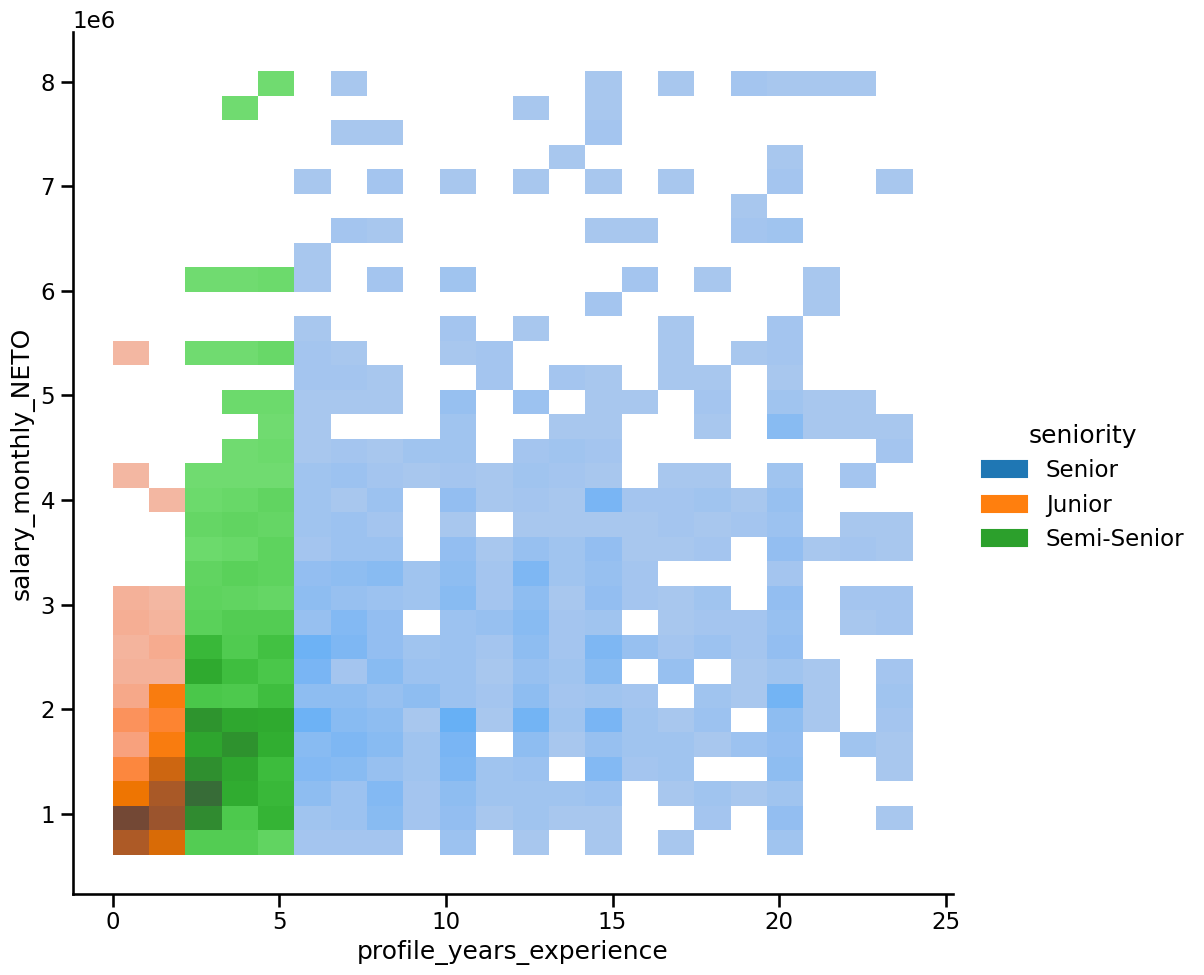

In [ ]:
df2=df1[(df1['salary_monthly_NETO']<df1['salary_monthly_NETO'].quantile(.99)) &(df1['profile_years_experience']<df1['profile_years_experience'].quantile(.95))] #& (df['work_province']=='Córdoba')]
seaborn.pairplot(data=df2, x_vars='profile_years_experience',y_vars='salary_monthly_NETO', hue='seniority', height=10,kind='hist')

La modalidad de trabajo predominante es remoto por lo que nos interesaria analizar las otra dos modalidades.
Podemos inferir que para salarios mayores a 2 millones predomina el trabajo hibrido como segunda opcion mientras que para los salarios mas bajos gana la presencialidad.


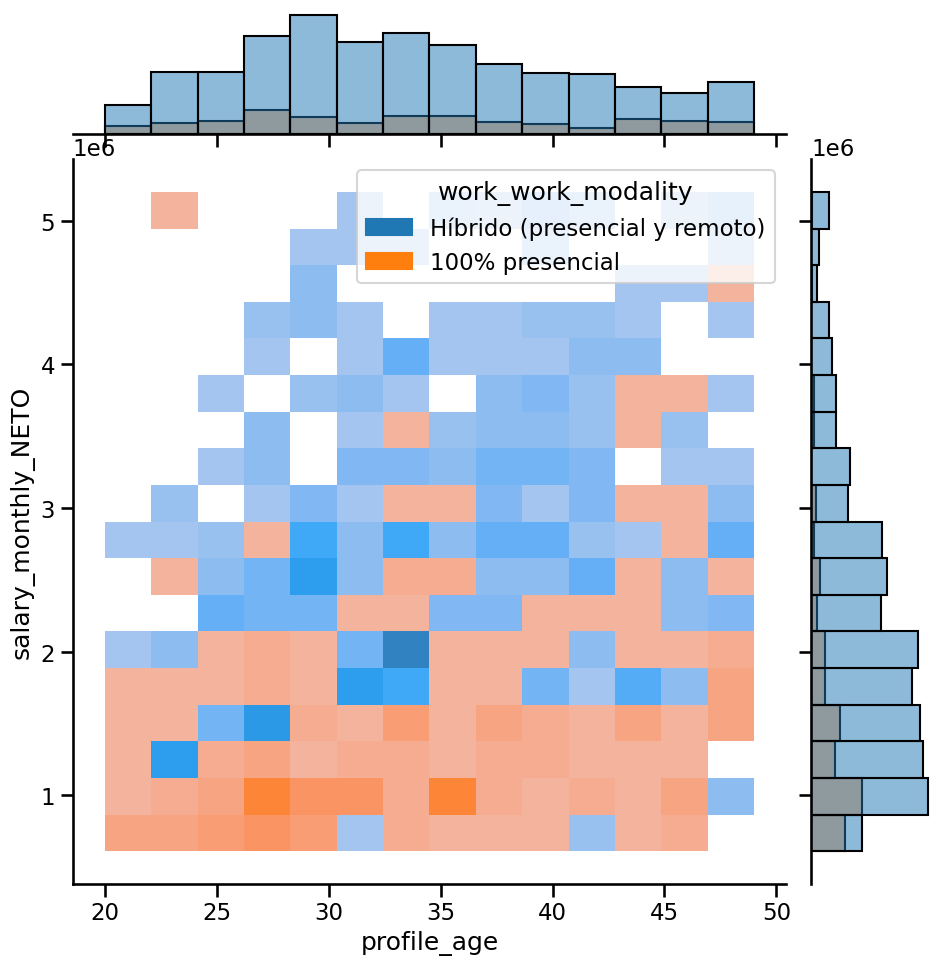

In [ ]:
df2=df1[(df1['profile_age']<df1['profile_age'].quantile(.95)) & (df1['salary_monthly_NETO']<df1['salary_monthly_NETO'].quantile(.95))]
df2 = df2.drop(df2[df2['work_work_modality'] == '100% remoto'].index)

seaborn.jointplot(data=df2, x='profile_age', y='salary_monthly_NETO', hue='work_work_modality',kind='hist', height=10)

En este ultimo podemos comparar la diferencia salarial que hay entre un cargo jerarquico como los es el de director/manager y el de solo un desarrollador.

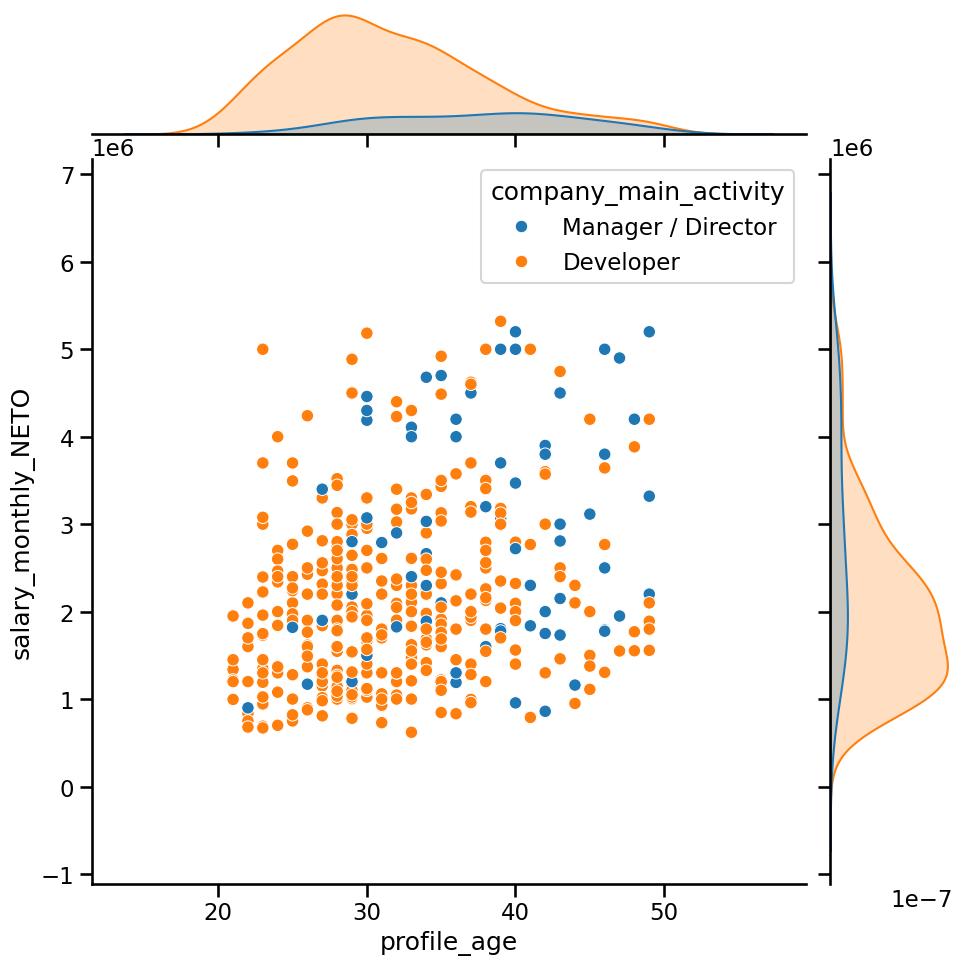

In [ ]:
df2 = df1[(df1['company_main_activity'] == 'Developer') | (df1['company_main_activity'] == 'Manager / Director')]
df1_=df2[(df2['salary_monthly_NETO']<df2['salary_monthly_NETO'].quantile(.95)) & (df2['profile_age']<df1['profile_age'].quantile(.95)) &  (df2.work_province == 'Ciudad Autónoma de Buenos Aires')]

seaborn.jointplot(data=df1_, x='profile_age',y='salary_monthly_NETO', hue='company_main_activity',kind='scatter', height=10) # Change x_vars to x and y_vars to y

## b) Asociación

* Necesitamos decidir si sacar o no la columna de salario bruto. Para hacer la encuesta más simple.
¿Existe una correlación entre el salario bruto y el neto? Que abordaje y medidas usaría



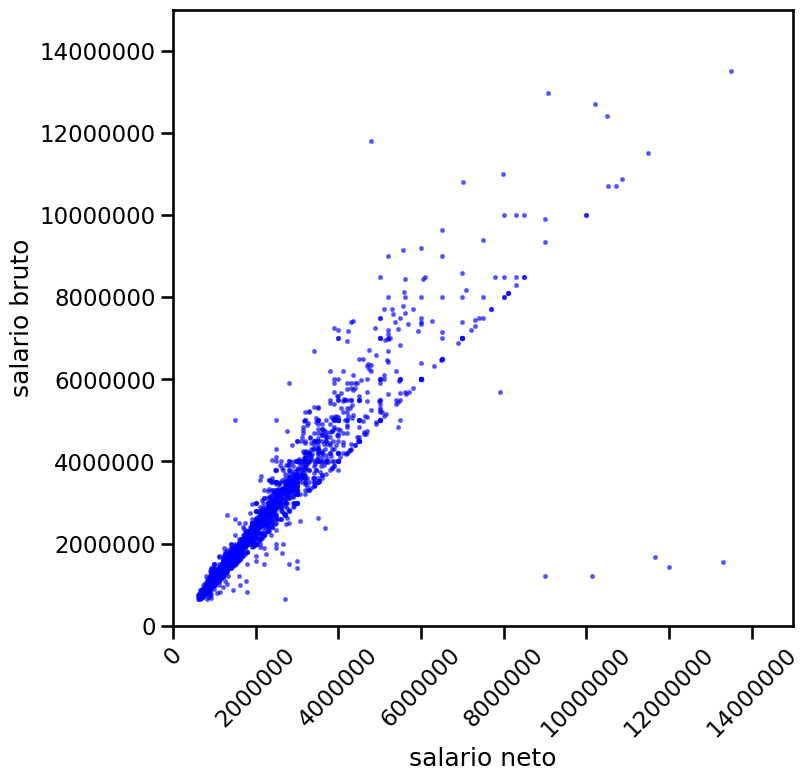

In [ ]:
#ANALISIS VISUAL: construimos grafico de dispersion para analizar como se comportan ambas variables

plt.figure(figsize=(8, 8))
plt.scatter(df1['salary_monthly_NETO'], df1['salary_monthly_BRUTO'], alpha=0.5, color='blue', s=5)
plt.xlabel('salario neto')
plt.ylabel('salario bruto')
## para evitar la notación científica en las etiquetas
plt.ticklabel_format(style='plain')
plt.xlim(0,15000000)
plt.xticks(rotation=45)
plt.ylim(0,15000000)
plt.show()

Visualmente se puede observar una tendencia lineal positiva, donde a medida que aumenta el salario neto tambien lo hace el salario bruto. Esta alineacion nos sugiere que existe una relacion fuerte entre ambas variables.

In [ ]:
#Medidas estadisticas: calculamos la matriz de covarianza para determinar si las variables crecen juntas y el coeficiente de correlacion
matcov=np.cov(df1.salary_monthly_BRUTO,df1.salary_monthly_NETO)
print('matriz de varianza covarianza:','\n',matcov,'\n')

corr=np.corrcoef(df1.salary_monthly_BRUTO,df1.salary_monthly_NETO)
print('matriz de correlaciones: \n ', corr,'\n')

print('correlación entra ambas variables: ',corr[0,1],'\n')

matriz de varianza covarianza: 
 [[3.17641814e+12 2.52979180e+12]
 [2.52979180e+12 2.41229625e+12]] 

matriz de correlaciones: 
  [[1.        0.9139041]
 [0.9139041 1.       ]] 

correlación entra ambas variables:  0.9139041028684862 



Con los valores obtenidos podemos concluir que ambas variables tienden a crecer juntas. Y que existe una relación lineal muy fuerte entre el salario bruto y el neto.

## c) Densidad condicional

Estudie la distribución del salario según el nivel de estudio.

Separe la población según el nivel de estudio (elija dos subpoblaciones numerosas) y grafique de manera comparativa ambos histogramas de la variable `'salary_monthly_NETO'`
¿Considera que ambas variables son independientes?
¿Qué analizaría al respecto?

Calcule medidas de centralización y dispersión para cada subpoblación






In [ ]:
df1['profile_studies_level'].value_counts()

,count
profile_studies_level,
Universitario,1483
Terciario,389
Posgrado/Especialización,144
Maestría,114
Secundario,86
Doctorado,21
Posdoctorado,12


In [ ]:
estudios_unicos=['Universitario', 'Terciario']

la desviacion estandar para Universitario es: 1527380.0364480177
la desviacion estandar para Terciario es: 1289674.2940865157


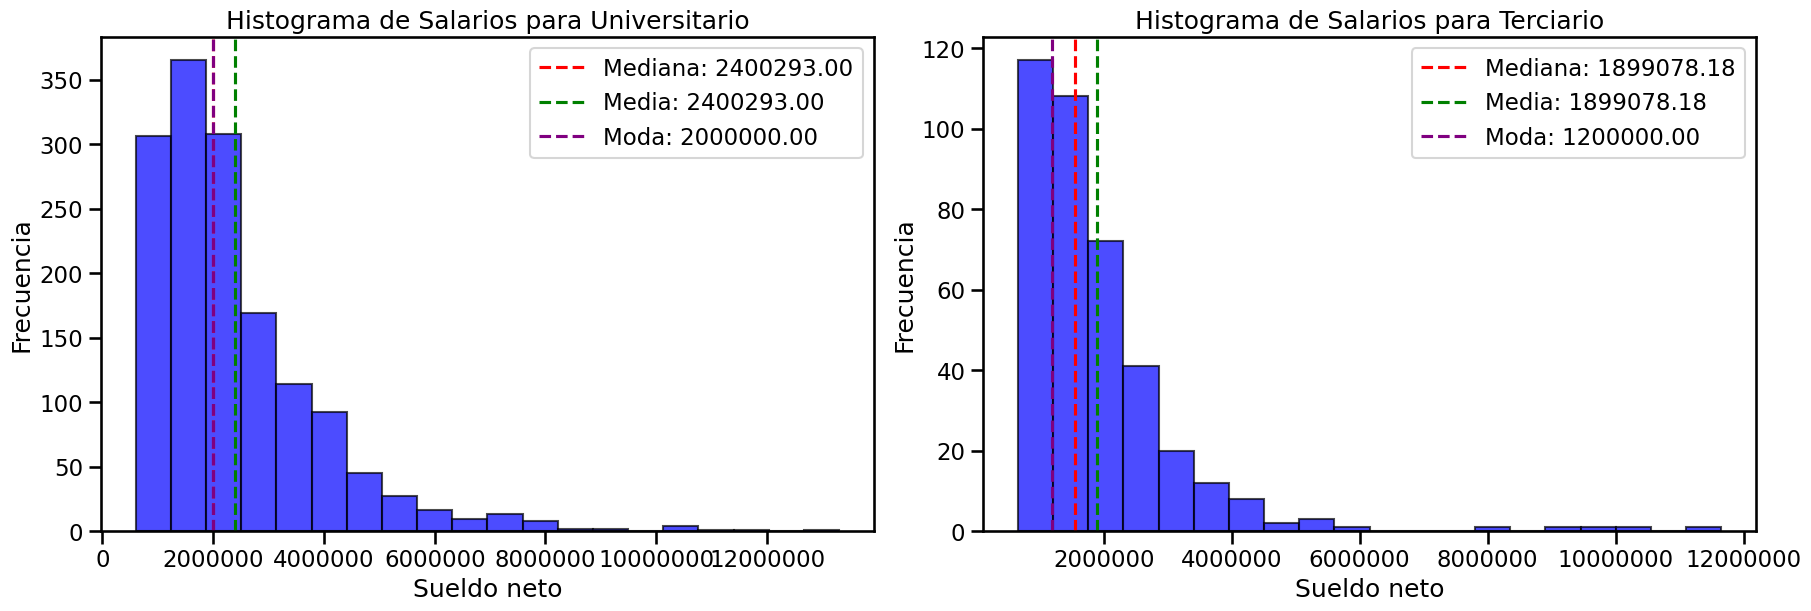

In [ ]:
# Crear subplots: 3 columnas, 2 filas
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
axes = axes.flatten()  # Aplanar para iterar fácilmente

# Crear histogramas para cada lenguaje
for i, estudio in enumerate(estudios_unicos):
    # Filtrar los datos para el lenguaje actual
    datos_estudios = df1[df1['profile_studies_level'] == estudio]['salary_monthly_NETO']
    # Calcular el salario medio
    salario_mediana = datos_estudios.median()
    salario_medio = datos_estudios.mean()
    salario_moda = datos_estudios.mode()
    desviacion_estandar = datos_estudios.std()
    print(f'la desviacion estandar para {estudio} es: {desviacion_estandar}')

    # Crear el histograma
    axes[i].hist(datos_estudios, bins=20, alpha=0.7, color='blue', edgecolor='black')
    axes[i].axvline(x=salario_mediana, color='red', linestyle='--', label=f'Mediana: {salario_medio:.2f}')
    axes[i].axvline(x=salario_medio, color='green', linestyle='--', label=f'Media: {salario_medio:.2f}')
    axes[i].axvline(x=salario_moda[0], color='purple', linestyle='--', label=f'Moda: {salario_moda[0]:.2f}')
    axes[i].legend()
    axes[i].set_title(f'Histograma de Salarios para {estudio}')
    axes[i].set_xlabel('Sueldo neto')
    axes[i].set_ylabel('Frecuencia')
    axes[i].ticklabel_format(style='plain')
plt.show()


##MEDIDAS DE DISPERSION


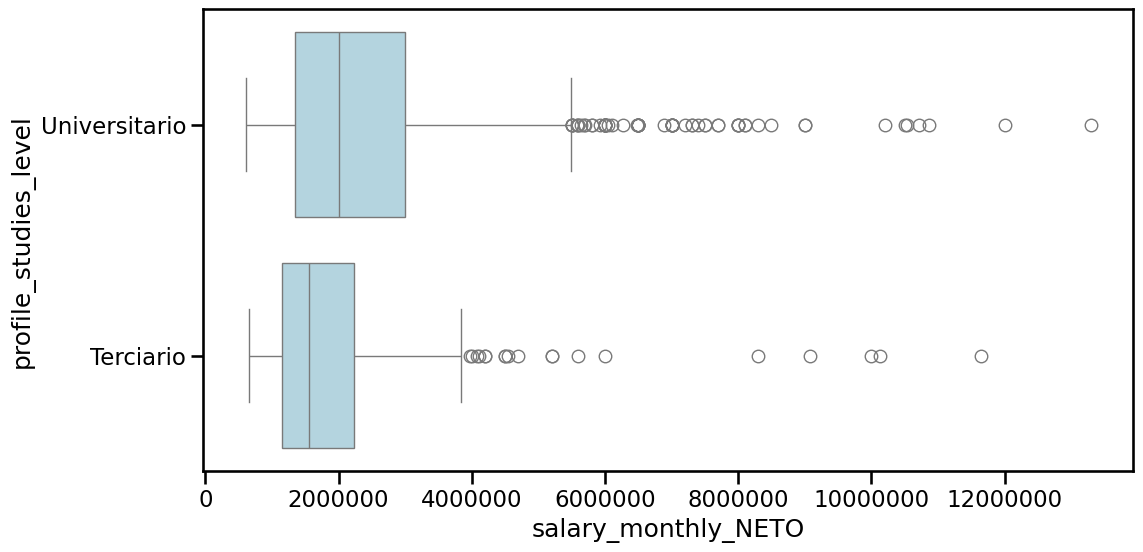

In [ ]:
# Filtrar el DataFrame para incluir solo los valores en la lista estudios_unicos
df_filtrado = df1[df1['profile_studies_level'].isin(estudios_unicos)]


plt.figure(figsize=(12, 6))
seaborn.boxplot(data=df_filtrado, x=df_filtrado['salary_monthly_NETO'], y=df_filtrado['profile_studies_level'],
                color='lightblue')
plt.ticklabel_format(style='plain', axis='x')

¿Considera que ambas variables son independientes?
¿Qué analizaría al respecto?
la probabilidad de cobrar mas que el promedio, varia de acuerdo al nivel de estudio? si las variables fuesen independientes no deberia cambiar.

In [ ]:
#Calculamos la media para definir el umbral de salario alto
avg_salary = df1['salary_monthly_NETO'].mean()  #salario promedio
print('%5.2f' % avg_salary)

2369157.23


In [ ]:
#Calculamos la probabilidad de tener un salario mayor al promedio
prob_above_avg = len(df1[df1['salary_monthly_NETO'] >= avg_salary]) / len(df1) #consideramos: "cobrar más"<-> cobrar más que el promedio
print('%5.6f' % prob_above_avg)

0.377056


In [ ]:
#Calculamos la probabilidad condicional, probabilidad de tener sueldo alto siendo universitario
is_above_avg = df1['salary_monthly_NETO']> avg_salary #lista de booleanos
universitario = df1.profile_studies_level == 'Universitario'  #lista debooleanos

intersection_count = len(df1[is_above_avg & universitario])
universitario_count=len(df1[ universitario])

prob_cond_above_avg_dada_uni=len(df1[is_above_avg & universitario])/len(df1[ universitario])

print('%5.4f' % prob_cond_above_avg_dada_uni)

0.4754


In [ ]:
#Calculamos la probabilidad condicional, probabilidad de tener sueldo alto siendo terciario
is_above_avg = df1['salary_monthly_NETO']> avg_salary #lista de booleanos
Terciario = df1.profile_studies_level == 'Terciario'  #lista debooleanos

intersection_count = len(df1[is_above_avg & Terciario])
universitario_count=len(df1[ Terciario])

prob_cond_above_avg_dada_terciario=len(df1[is_above_avg & Terciario])/len(df1[ Terciario])

print('%5.4f' % prob_cond_above_avg_dada_terciario)

0.1974


## NO SON INDEPENDIENTES
Se compararon las probabilidades de tener un salario por encima del promedio según el nivel de estudios.
Los resultados muestran que:

P(sueldo alto / universitario) = 0.4754

P(sueldo alto / terciario) = 0.1974

Como estas probabilidades son distintas, concluimos que el nivel de estudios si influye sobre el salario.
Por lo tanto, las variables no son independientes: a mayor nivel educativo, mayor es la probabilidad de tener un salario mayor al promedio.

## d) Densidad Conjunta condicional

Elija dos variables numéricas y una categórica.
Estudie la dispersión (scatterplot) de las dos variables discriminando en color por la variable categórica (ayuda: hue en seaborn)


In [ ]:
#Para este punto vamos a analizar el salario neto vs la edad por genero
#Primer paso limpiamos las filas que tienen salario en NULL
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/master/sysarmy_survey_2025_processed.csv'
df_crudo = pd.read_csv(url)

df_clean_salary= df_crudo[df_crudo.salary_monthly_NETO.notnull()].copy()

In [ ]:
#Verificamos la existencia de valores atipicos para ellos analizamos los máximos y mínimos para el salario y la edad.
salary = 'salary_monthly_NETO'

df_mayor_que_100k = df_clean_salary[df_clean_salary[salary] > 100000]
df_filtered_salary= df_mayor_que_100k[df_mayor_que_100k[salary] < 83000000]

salario_min = df_filtered_salary[salary].min()
salario_max = df_filtered_salary[salary].max()

print(f"Salario más bajo: {salario_min }")
print(f"Salario más alto: {salario_max}")


edad_min = df_filtered_salary['profile_age'].min()
edad_max = df_filtered_salary['profile_age'].max()

print(f"edad minima: {edad_min}")
print(f"edad maxima: {edad_max}")

df_filtered_edad = df_filtered_salary[df_filtered_salary['profile_age'] < 70]

print(f"Nueva edad minima: {df_filtered_edad['profile_age'].min()}")
print(f"Nueva edad maxima: {df_filtered_edad['profile_age'].max()}")

Salario más bajo: 107500.0
Salario más alto: 30000000.0
edad minima: 19
edad maxima: 3040
Nueva edad minima: 19
Nueva edad maxima: 69


In [ ]:
#Para mejorar la legibilidad del grafico creamos una columna "genero_simplificado", esto se dedidió asi
#porque la variable original "profile_gender" contiene multiples identidades y muchas de ellas con muy baja
#representacion numerica.

def agrupar_genero(genero):
    if genero == 'Hombre Cis':
        return 'Hombre Cis'
    elif genero == 'Mujer Cis':
        return 'Mujer Cis'
    else:
        return 'Otro'

df_filtered_edad['genero_simplificado'] = df_filtered_edad['profile_gender'].apply(agrupar_genero)
df_filtered_edad[:10]


<ipython-input-20-50db71a536df>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_edad['genero_simplificado'] = df_filtered_edad['profile_gender'].apply(agrupar_genero)


,Unnamed: 0,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,...,work_on_call_duty,salary_on_call_duty_charge,aclara_el_numero_que_ingresaste_en_el_campo_anterior,profile_age,profile_gender,habias_respondido_nuestra_encuesta_en_ediciones_anteriores,sueldo_dolarizado,seniority,_sal,genero_simplificado
0,0,Ciudad Autónoma de Buenos Aires,Part-Time,Staff (planta permanente),6500000.00,5800000.00,Cobro parte del salario en dólares,NaN,De uno a tres sueldos,Performance de la compañía,...,NaN,NaN,NaN,45,Hombre Cis,Sí,True,Senior,6500000.00,Hombre Cis
1,1,Ciudad Autónoma de Buenos Aires,Full-Time,Contractor,12700000.00,10200000.00,Cobro todo el salario en dólares,NaN,Un sueldo,Performance de la compañía,...,No,0.0,Bruto,32,Mujer Cis,Sí,True,Senior,12700000.00,Mujer Cis
2,2,Córdoba,Full-Time,Staff (planta permanente),3952805.00,3137662.00,Cobro parte del salario en dólares,985,No,No recibo bono,...,NaN,NaN,NaN,29,Hombre Cis,Sí,True,Semi-Senior,3952805.00,Hombre Cis
3,3,Ciudad Autónoma de Buenos Aires,Part-Time,Staff (planta permanente),1606000.00,1360000.00,Cobro parte del salario en dólares,1004,No,No recibo bono,...,NaN,NaN,NaN,25,Hombre Cis,Sí,True,Semi-Senior,1606000.00,Hombre Cis
5,5,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),2670205.00,2167989.00,Cobro parte del salario en dólares,986,No,No recibo bono,...,No,0.0,Porcentaje de mi sueldo bruto,48,Hombre Cis,Sí,True,Senior,2670205.00,Hombre Cis
6,6,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),4000000.00,4000000.00,Cobro todo el salario en dólares,NaN,No,No recibo bono,...,No,0.0,Bruto,50,Hombre Cis,Sí,True,Senior,4000000.00,Hombre Cis
7,7,Córdoba,Full-Time,Staff (planta permanente),4200000.00,3600000.00,Cobro parte del salario en dólares,1070,No,No recibo bono,...,"Sí, pasiva",0.0,Porcentaje de mi sueldo bruto,43,Hombre Cis,Sí,True,Senior,4200000.00,Hombre Cis
8,8,Buenos Aires,Full-Time,Freelance,3000000.00,2000000.00,Mi sueldo está dolarizado (pero cobro en moned...,1150,No,No recibo bono,...,NaN,NaN,NaN,41,Hombre Cis,No,True,Senior,3000000.00,Hombre Cis
9,9,Buenos Aires,Full-Time,Staff (planta permanente),3953142.06,3258576.49,Mi sueldo está dolarizado (pero cobro en moned...,NaN,Un sueldo,Performance de la compañía,...,NaN,NaN,NaN,47,Hombre Cis,Sí,True,Senior,3953142.06,Hombre Cis
11,11,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),1212500.00,2071375.00,Mi sueldo está dolarizado (pero cobro en moned...,NaN,No,Performance de la compañía,...,NaN,NaN,NaN,28,Hombre Cis,Sí,True,Senior,1212500.00,Hombre Cis


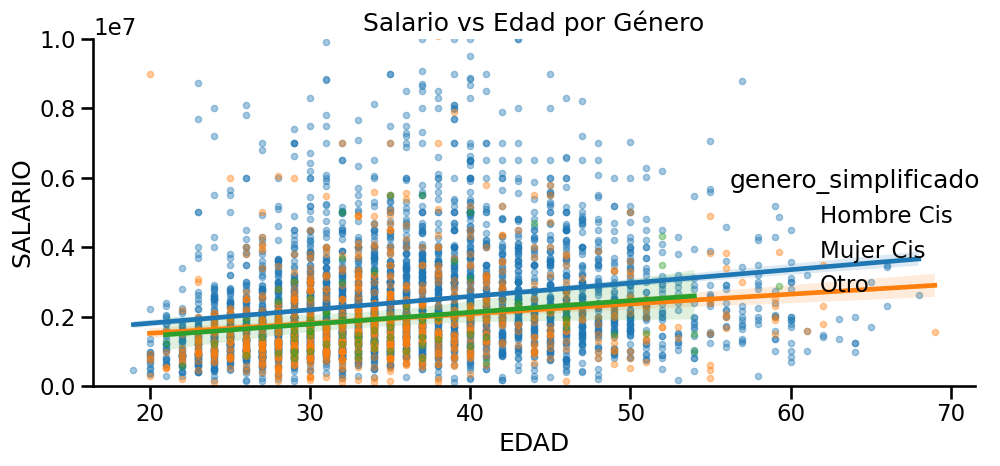

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(
    data=df_filtered_edad,
    x='profile_age',
    y='salary_monthly_NETO',
    hue='genero_simplificado',
    aspect=1.5,
    height=5,
    scatter_kws={'alpha': 0.4, 's': 20}
)
plt.title("Salario vs Edad por Género")
plt.xlabel("EDAD")
plt.ylabel("SALARIO")
plt.ylim(0, 10000000)
plt.tight_layout()
plt.show()


**Hombre Cis** tiene una tendencia mas fuerte por lo que se puede concluir a mayor edad, mayor salario.

**Mujer Cis** tiene una tendencia mas suave tambien aumenta con la edad, pero mas lento que en hombres.

Los otros géneros tienen una tendencia mas plana, se puede concluir que la progresión salarial es menor o más variable.